$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 1.5

## 理论

设 $\boldsymbol{x} = (x_1, \dots, x_p)'$ 为 $p$ 个输入变量（也称为影响因子），$y$ 为输出变量（或称响应值）。假设统计模型：

$$
y = h(\boldsymbol{x}) + \epsilon
\tag{1.1}
$$

式中 $h(\boldsymbol{x})$ 代表输入输出关系（响应曲面），$\epsilon$ 为随机误差，通常假定 $\epsilon \sim \mathcal{N}(0, \sigma^2)$，其中 $\sigma^2$ 为随机误差的方差。假设我们开展一项单因素试验，该因素设置两个取值（也称为水平）：$x=0$ 和 $x=1$，每种水平设置 3 次重复试验。试验数据如图 1.5 中蓝色实心圆点所示。设 $h(\cdot)$ 为图中黑色实线代表的函数，试验人员并不知晓该函数形式。假设我们采用模型 $y_i = \beta_0 + \beta_1x_i + \epsilon_i$ 拟合数据，其中对 $i=1,\dots,n$（本例中 $n=6$），$\epsilon_i$ 独立同分布，服从正态分布 $\mathcal{N}(0, \sigma^2)$。拟合得到的直线以及 95% 置信区间展示在图的左侧子图，高斯过程的拟合结果同样展示在该图的右侧子图。

线性回归的预测不确定性包含参数估计（$\hat{\beta}_0$ 和 $\hat{\beta}_1$）带来的不确定性以及随机误差（$\epsilon$）。该模型在取值端点处（$x=0$ 和 $x=1$）不确定性最大，在中点位置（$x=0.5$）不确定性最小。与之不同，高斯过程回归属于非参数回归方法，因此其预测不确定性包含关于函数 $h(\cdot)$ 的不确定性与随机误差。在已有观测数据的位置，它的不确定性最低，而在区间中点处不确定性达到峰值，这与线性回归的特征恰好相反！

当因子数量（$p$）较多，而实验次数（$n$）较少时，高斯过程回归在边界处同样会产生较大不确定性，该现象与线性回归所得结论一致。因此，采用线性回归框架或高斯过程回归框架大概率会得到相同结果。不过，若依托线性回归框架开展研究，会对最优设计的探索带来一定局限。

## 实践

创建画布宽 20 英寸、高 10 英寸。将画布分为 1x2。设 n=6。创建向量 $c(0,1)$，其中 0、1 各重复 n/2 次。依据函数

$$
f=\frac{\sin(10\pi x)}{1+64(x-0.25)^2}+x^2
$$

计算 x 对应的函数值 f。设置种子为 7，生成服从 $\mathcal{N}(0,1)$ 的 n 个随机数，乘 0.1 后作为噪声加到 f(x) 上，令其为 y。定义图像 x 的下界为 l=-.25，上界为 u=1.25。创建从 l 到 u，长度 301 的序列 test，并计算其对应的函数值 f(test)，令其为 truey。绘制真实函数的图像，其中类型为 l，线宽为 4，x 轴范围为 c(l,u)，y 轴范围为 c(min(y)-.5,1.5)，坐标轴大小为 2，轴标签为 2，标题为“线性回归”，大小为 3。叠加预测点图像，其中点型为 16，大小为 4，颜色为 blue。

使用线性模型预测函数 predict.lm() 对 y 进行线性拟合并预测，其中模型为 y 对 x 的线性拟合，数据集为数据框 data.frame(x=test)，本质上就是把 test 封装成列名为 x 的数据框，开启预测区间，将拟合矩阵命名为 pred，其中第 1 列为预测值，第 2 列为预测区间下界，第 3 列为预测区间上界。叠加预测函数的图像，其中颜色为 3，线宽为 4，线型为 2。令 pred 第 2 列为 low，第 3 列为 up，绘制预测区间多边形 c，其中颜色为 50% 的 pink，不显示边界。添加图例，位置在 (-.4,1.65)，内容为 c("真实值","预测值")，线型为 c(1,2)，颜色为 c(2,3)，线宽为 c(4,4)，不显示图例边框，大小为 2。

绘制真实函数的图像，其中类型为 l，线宽为 4，x 轴范围为 c(l,u)，y 轴范围为 c(min(y)-.5,1.5)，坐标轴大小为 2，轴标签为 2，标题为“线性回归”，大小为 3。叠加预测点图像，其中点型为 16，大小为 4，颜色为 blue。导入包 rkiging，使用 Fit.Kriging() 函数对观测点进行克里金拟合，其中由于有噪声，故不使用插值，自动拟合核函数，使用普通克里金模型，即 OK，核函数选用高斯核，为一个列名为 Gaussian 的列表。再使用 Predict.Kriging() 函数对拟合模型进行预测，其中数据集为数据框 data.frame(x=test)，本质上就是把 test 封装成列名为 x 的数据框，将预测结果命名为 pred，列表 pred 的 mean 列代表预测结果，sd 列代表预测标准差。绘制预测曲线图像，其中颜色为 3，线宽为 4，线型为 2。由于噪声服从正态分布，故依据 2-$\sigma$ 原则，mean 列上下 2*sd 列即为 95% 预测区间的上下界，分别命名为 low，up。绘制预测区间多边形，其中颜色为 50% 的 pink，不显示边框。添加图例，位置在 (-.4,1.65)，内容为 c("真实值","预测值")，线型为 c(1,2)，颜色为 c(1,3)，线宽为 c(4,4)，不显示图例边框，大小为 2。将画布还原回 1x1。

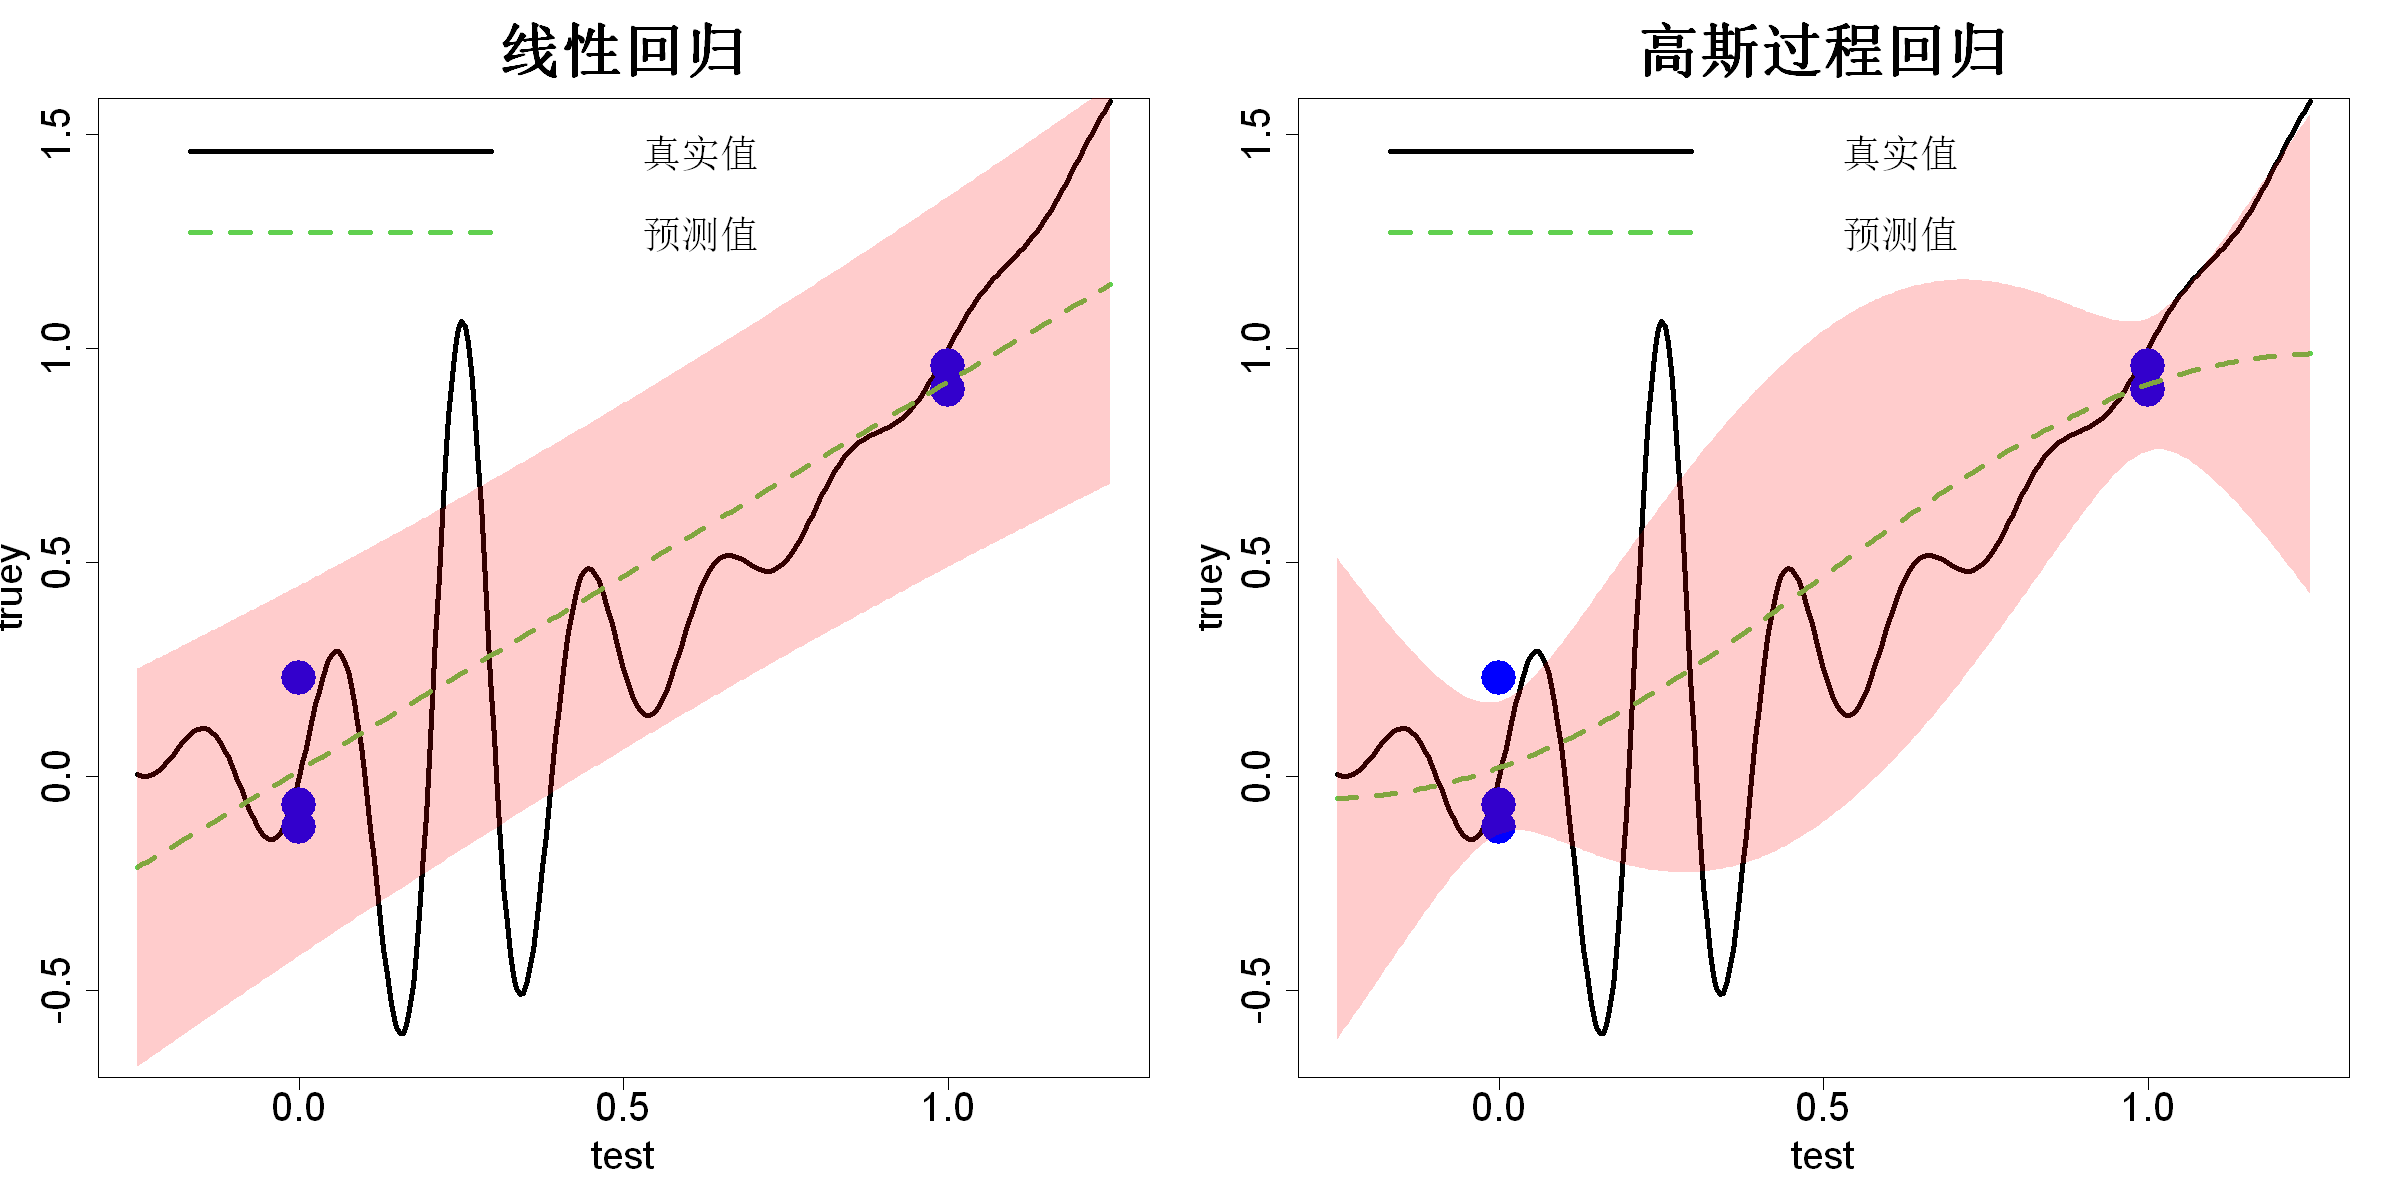

In [ ]:
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
n=6
x=rep(c(0,1),c(n/2,n/2))
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
set.seed(7)
y=f(x)+.1*rnorm(n)
l=-.25;u=1.25
test=seq(l,u,length=301)
truey=f(test)
plot(test,truey,type="l",lwd=4,xlim=c(l,u),ylim=c(min(y)-.5,1.5),cex.axis=2,cex.lab=2,main="线性回归",cex.main=3)
points(x,y,pch=16,cex=4,col="blue")

pred=predict.lm(lm(y~x),newdata=data.frame(x=test),interval="prediction")
lines(test,pred[,1],col=3,lwd=4,lty=2)
low=pred[,2]
up=pred[,3]
polygon(c(test,rev(test)),c(low,rev(up)),col=adjustcolor("red",alpha.f=0.2),border=NA)
legend(-.4,1.65,legend=c("真实值","预测值"),lty=c(1,2),col=c(1,3),lwd=c(4,4),bty="n",cex=2)

plot(test,truey,type="l",lwd=4,xlim=c(l,u),ylim=c(min(y)-.5,1.5),main="高斯过程回归",cex.main=3,cex.axis=2,cex.lab=2)
points(x,y,pch=16,col="blue",cex=4)
library(rkriging)
pred=Fit.Kriging(x,y,interpolation=FALSE,fit=TRUE,model="OK",kernel.parameters=list(type="Gaussian"))|>
Predict.Kriging(data.frame(x=test))
lines(test,pred$mean,col=3,lwd=4,lty=2)
low=pred$mean-2*pred$sd
up=pred$mean+2*pred$sd
polygon(c(test,rev(test)),c(low,rev(up)),col=adjustcolor("red",alpha.f=0.2),border=NA)
legend(-.4,1.65,legend=c("真实值","预测值"),lty=c(1,2),col=c(1,3),lwd=c(4,4),bty="n",cex=2)
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$